In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load data

In [5]:
# number of jobs
job_number = 100

# physical bit-flip error rate
px_list = np.logspace(-7,np.log10(5e-5),10)
# number of preselected rounds
preselect_list = range(0,4)

# Save logical error
Logical_Error = np.full((len(preselect_list),len(px_list)),np.nan)
# Save logical error uncertainty
Logical_Error_u = np.full((len(preselect_list),len(px_list)),np.nan)

# Save logical error without flag qubit
Logical_Error_wo_flag = np.full((len(preselect_list),len(px_list)),np.nan)
# Save logical error uncertainty without flag qubit
Logical_Error_wo_flag_u = np.full((len(preselect_list),len(px_list)),np.nan)

# loop through preselected rounds
for preselect in preselect_list:
    # loop through bitflip error rate
    for index_px in range(len(px_list)): 
        nb_accepted = 0
        nb_fail = 0
        nb_accepted_wo_flag = 0
        nb_fail_wo_flag = 0
        
        # loop through jobs
        for index in range(job_number):
            result = json.load(open(f'Results/result_{index_px}_{index}.json', 'r'))

            if preselect < len(result['preselected&accepted&noflag&gap&fail']):
                nb_fail += result['preselected&accepted&noflag&gap&fail'][preselect]
                nb_accepted += result['preselected&accepted&noflag&gap'][preselect]
                
            if preselect < len(result['preselected&accepted&gap&fail']):
                nb_fail_wo_flag += result['preselected&accepted&gap&fail'][preselect]
                nb_accepted_wo_flag += result['preselected&accepted&gap'][preselect]

        if nb_accepted != 0:
            Logical_Error[preselect,index_px] = nb_fail/nb_accepted
            Logical_Error_u[preselect,index_px] = 1.96*np.sqrt(nb_fail/nb_accepted**2)
            
        if nb_accepted_wo_flag != 0:
            Logical_Error_wo_flag[preselect,index_px] = nb_fail_wo_flag/nb_accepted_wo_flag
            Logical_Error_wo_flag_u[preselect,index_px] = 1.96*np.sqrt(nb_fail_wo_flag/nb_accepted_wo_flag**2)

# Plot logical error rate

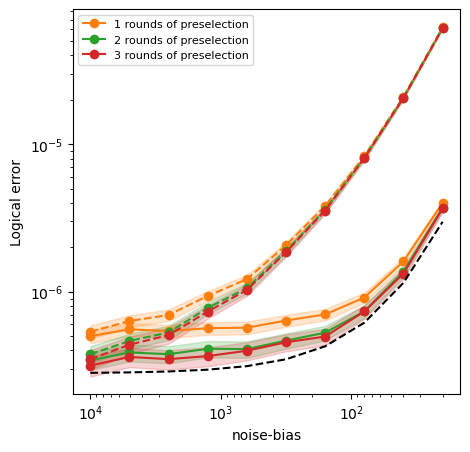

In [15]:
plt.figure(figsize=(5,5))         

color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# loop through preselected rounds
for i, preselect in enumerate(preselect_list[1:4]):
    color = color_cycle[i+1 % len(color_cycle)]
    
    # with flag qubit
    plt.plot(1e-3/px_list, Logical_Error[preselect], '-o', label=f'{preselect} rounds of preselection', color=color)
    plt.fill_between(1e-3/px_list,Logical_Error[preselect] - Logical_Error_u[preselect],
                     Logical_Error[preselect] + Logical_Error_u[preselect],alpha=0.2,color=color)

    # without flag qubit
    plt.plot(1e-3/px_list, Logical_Error_wo_flag[preselect], '--o', color=color)
    plt.fill_between(1e-3/px_list,Logical_Error_wo_flag[preselect] - Logical_Error_wo_flag_u[preselect],
                     Logical_Error_wo_flag[preselect] + Logical_Error_wo_flag_u[preselect],alpha=0.2,color=color)

# theoritcal 35p^3 of distillation
plt.plot(1e-3/px_list,35*(2/3*1e-3 + 1e-3 + 1e-3/3 + px_list*6*8)**3,'--',c='k')

plt.gca().invert_xaxis()

plt.legend(loc = 'upper left',fontsize = 8)
plt.yscale('log')
plt.loglog()
plt.xlabel('noise-bias')
plt.ylabel('Logical error')
plt.show()

In [14]:
import pandas as pd
column_names = [f"px = {px_list[i]:.2e}" for i in range(10)]
row_names = [f"preselection {i} round(s)" for i in range(4)]
df = pd.DataFrame(Logical_Error, columns=column_names, index=row_names)
df = df.style.format("{:.2e}")
df

,px = 1.00e-07,px = 1.99e-07,px = 3.98e-07,px = 7.94e-07,px = 1.58e-06,px = 3.16e-06,px = 6.30e-06,px = 1.26e-05,px = 2.51e-05,px = 5.00e-05
preselection 0 round(s),2.27e-05,2.29e-05,2.26e-05,2.29e-05,2.30e-05,2.39e-05,2.42e-05,2.61e-05,2.96e-05,3.85e-05
preselection 1 round(s),5.00e-07,5.57e-07,5.41e-07,5.66e-07,5.71e-07,6.38e-07,7.02e-07,9.14e-07,1.61e-06,4.01e-06
preselection 2 round(s),3.43e-07,3.88e-07,3.78e-07,4.11e-07,4.09e-07,4.67e-07,5.28e-07,7.37e-07,1.37e-06,3.70e-06
preselection 3 round(s),3.16e-07,3.61e-07,3.49e-07,3.66e-07,3.98e-07,4.55e-07,4.97e-07,7.35e-07,1.33e-06,3.68e-06
